Task 1 [10 points] Apply BFS and DFS on trees and graphs. You can use simple examples for
your practice.

In [1]:
from collections import deque

# Graph (Adjacency List)
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

# BFS
def bfs(graph, start):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            print(node, end=" ")
            visited.add(node)
            queue.extend(graph[node])

# DFS
def dfs(graph, node, visited=set()):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)
        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

print("BFS Traversal:")
bfs(graph, 'A')

print("\nDFS Traversal:")
dfs(graph, 'A')

BFS Traversal:
A B C D E F 
DFS Traversal:
A B D E F C 

Task 2 [10 points]
1. Generate random and unique numbers of ranges 1000,40,000,80,000,200,000 and
1,000,000. So now you have 5 sets of inputs, build the tree for each sets (each set has its
own list)
2. Apply BFS and DFS on each sets and calculate the time taken for the execution to find
that goal through BFS and DFS.
3. Goal should be lis[total_len – 220]
4. Make a data frame for your results as shown below.
5. Finally plot the bar chart of the time taken by each search for example (on X-axis the data
will be 1000,40,000,80,000,200,000 and 1,000,000.) and on the Y axis the data will be
the seconds it took while searching

   Input Size  BFS Time  DFS Time
0        1000  0.000088  0.000028
1       40000  0.003833  0.000435
2       80000  0.008009  0.003225
3      200000  0.020551  0.003833
4     1000000  0.061049  0.014600


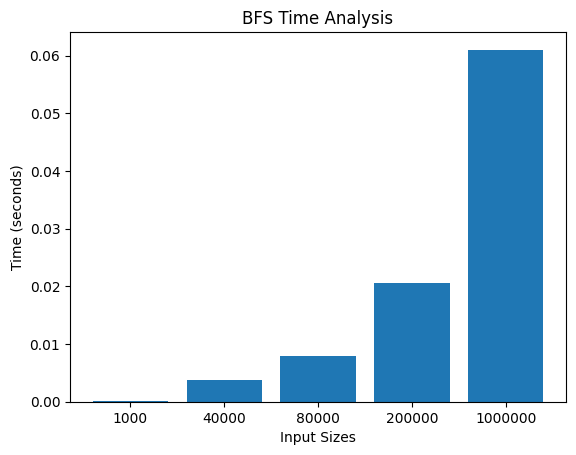

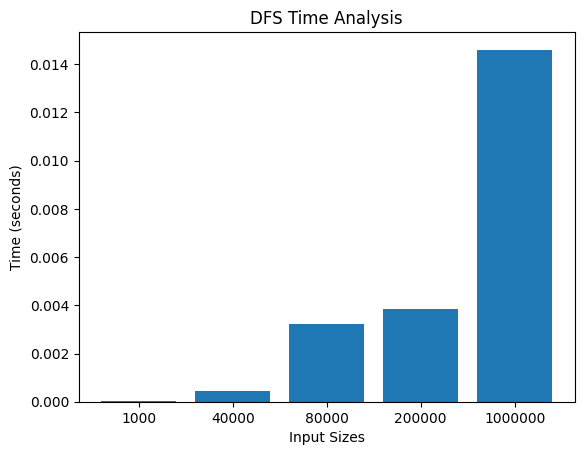

In [2]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# BFS Search
def bfs_search(lst, goal):
    queue = deque(lst)
    while queue:
        if queue.popleft() == goal:
            return True

# DFS Search
def dfs_search(lst, goal):
    stack = lst.copy()
    while stack:
        if stack.pop() == goal:
            return True

sizes = [1000, 40000, 80000, 200000, 1000000]

bfs_times = []
dfs_times = []

for size in sizes:
    data = random.sample(range(size*10), size)
    goal = data[len(data) - 220]

    # BFS Time
    start = time.time()
    bfs_search(data, goal)
    bfs_times.append(time.time() - start)

    # DFS Time
    start = time.time()
    dfs_search(data, goal)
    dfs_times.append(time.time() - start)

# DataFrame
df = pd.DataFrame({
    "Input Size": sizes,
    "BFS Time": bfs_times,
    "DFS Time": dfs_times
})

print(df)

# Plot Graph
plt.bar(range(len(sizes)), bfs_times)
plt.xlabel("Input Sizes")
plt.ylabel("Time (seconds)")
plt.title("BFS Time Analysis")
plt.xticks(range(len(sizes)), sizes)
plt.show()

plt.bar(range(len(sizes)), dfs_times)
plt.xlabel("Input Sizes")
plt.ylabel("Time (seconds)")
plt.title("DFS Time Analysis")
plt.xticks(range(len(sizes)), sizes)
plt.show()

Task 3 [10 points]
Imagine you're a tourist in Pakistan, and you want to travel from Islamabad to Karachi. You
want to find the shortest route in terms of the number of cities you need to travel through. The
cities are connected through highways, and your goal is to find the shortest path using BFS.
Cities and Their Connections (Graph):
You will use the following cities and their connections for this scenario:
• Islamabad is connected to Rawalpindi, Lahore, and Peshawar.
• Rawalpindi is connected to Islamabad, Peshawar, and Quetta.
• Peshawar is connected to Islamabad, Rawalpindi, and Quetta.
• Lahore is connected to Islamabad, Multan, and Quetta.
• Multan is connected to Lahore, Karachi, and Quetta.
• Quetta is connected to Rawalpindi, Peshawar, Multan, and Karachi.
• Karachi is connected to Multan and Quetta.

In [3]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

# Find shortest path
path = bfs_shortest_path(graph, "Islamabad", "Karachi")

print("Shortest Path:", " -> ".join(path))

Shortest Path: Islamabad -> Rawalpindi -> Quetta -> Karachi
